In [145]:
from qiskit import QuantumCircuit, QuantumRegister, transpile
from qiskit.circuit import Parameter, Instruction, ParameterExpression
from qiskit_aer import AerSimulator
import numpy as np
import networkx as nx

In [ ]:
def is_equal_to_with_parity(n, j, b):
    ceil_log_n2 = int(np.ceil(np.log2(n+2)))
    ctrl_state = 2 * j + b
    circ = QuantumCircuit(ceil_log_n2 + 1 + 1)
    circ.mcx(list(range(circ.num_qubits-1)), circ.num_qubits - 1, ctrl_state=ctrl_state)
    return circ

In [ ]:
def is_equal_to_without_parity(n, j):
    ceil_log_n2 = int(np.ceil(np.log2(n+2)))
    ctrl_state = j 
    circ = QuantumCircuit(ceil_log_n2 + 1)
    circ.mcx(list(range(circ.num_qubits-1)), circ.num_qubits - 1, ctrl_state=ctrl_state)
    return circ

In [28]:
is_equal_no_parity = is_equal_to_without_parity(5, 4)
is_equal_no_parity.draw(fold=-1)

q_0: ──o──
       │  
q_1: ──o──
       │  
q_2: ──■──
     ┌─┴─┐
q_3: ┤ X ├
     └───┘

In [26]:
is_equal_parity = is_equal_to_with_parity(5, 4, 0)
is_equal_parity.draw(fold=-1)

q_0: ──o──
       │  
q_1: ──o──
       │  
q_2: ──o──
       │  
q_3: ──■──
     ┌─┴─┐
q_4: ┤ X ├
     └───┘

In [30]:
qc = QuantumCircuit(5)
qc.append(is_equal_parity, range(is_equal_parity.num_qubits))
qc.append(is_equal_no_parity, range(1, is_equal_no_parity.num_qubits + 1))
qc.decompose().draw(fold=-1)

q_0: ──o───────
       │       
q_1: ──o────o──
       │    │  
q_2: ──o────o──
       │    │  
q_3: ──■────■──
     ┌─┴─┐┌─┴─┐
q_4: ┤ X ├┤ X ├
     └───┘└───┘

In [72]:
def controlled_copy_with_swap(circuit: QuantumCircuit, registers: dict, K: int, t: int, parameter: Parameter | None = None) -> QuantumCircuit:
    """
    Appends a controlled copy circuit that also shuffles all the registers in the copy list forward one place.
    |0>|to_be_copied>|copy_1>|copy_2>...|copy_K> -> |0>|to_be_copied>|copy_1>|copy_2>...|copy_K>
    |1>|to_be_copied>|copy_1>|copy_2>...|copy_K> -> |1>|to_be_copied>|copy_K+ to_be_copied>|copy_1 >...|copy_K-1> , where the addition is bitwise.
    
    If copy_K is not empty (i.e. all-zero ket), applies a penalty phase.
    n: number of gfa segments
    K: number of copy registers
    """
    # Penalise only when computing, not uncomputing, and only when trying to make a new copy.
    # If final register not empty, visited a node too many times. Apply a large penalty, since we cannot account for the next graph step. 
    # It also messes up already-tracked graph steps, overwriting them with a bitwise-and with the new step.
    # So apply 3x penalty.
    if parameter is not None:
        circuit.mcx(
            [circuit.find_bit(registers['flag'][0]).index] + list(range(circuit.find_bit(registers[f'next_node_{K-1}'][1]).index, circuit.find_bit(registers[f'next_node_{K-1}'][-1]).index + 1)), 
            circuit.find_bit(registers['visits_flag'][0]).index, 
            ctrl_state=1
        )
        circuit.cp(-parameter, circuit.find_bit(registers['flag'][0]).index, circuit.find_bit(registers['visits_flag'][0]).index)
        circuit.mcx(
            [circuit.find_bit(registers['flag'][0]).index] + list(range(circuit.find_bit(registers[f'next_node_{K-1}'][1]).index, circuit.find_bit(registers[f'next_node_{K-1}'][-1]).index + 1)), 
            circuit.find_bit(registers['visits_flag'][0]).index, 
            ctrl_state=1
        )
        circuit.x(circuit.find_bit(registers['visits_flag'][0]).index)
        circuit.cp(parameter, circuit.find_bit(registers['flag'][0]).index, circuit.find_bit(registers['visits_flag'][0]).index)
        circuit.x(circuit.find_bit(registers['visits_flag'][0]).index)
    
    # For each qubit i in final copy register:
    for i in range(registers[f'next_node_{K-1}'].size):
        # Swap down to ith position in the first copy register, conditioned on the c_copy_flag
        start_idx = circuit.find_bit(registers[f'next_node_{K-1}'][i]).index
        end_idx = circuit.find_bit(registers[f'next_node_{0}'][i]).index
        for idx in range(start_idx, end_idx, -1):
            circuit.cswap(circuit.find_bit(registers['flag'][0]).index, idx, idx-1)
            
    # Copy the to_be_copied register into the first next_node register, conditioned on the c_copy_flag
    for i in range(registers[f'solution_{t}'].size):
        circuit.ccx(
            circuit.find_bit(registers['flag'][0]).index, 
            circuit.find_bit(registers[f'solution_{t}'][i]).index, 
            circuit.find_bit(registers['next_node_0'][i]).index
        )
    return circuit


def compute_next_nodes_with_parity(
        circuit: QuantumCircuit, registers: dict, j: int, b:int, n: int, K: int, T: int, parameter: Parameter | None
) -> QuantumCircuit:
    """
    Appends a compute_next_nodes subroutine to a circuit, which initialises registers .
    For t in 0..T-2:
        Checks if the t th solution register encodes j and flips a flag if so.
        If the flag is set, shuffles the next_node registers forward one place and copies the (t+1)th solution register to the next_node registers.
        Resets the flag.
    """
    if b not in (0, 1):
        raise Exception(f'b should be binary. Current: {b}')
    
    
    is_equal_circ = is_equal_to_with_parity(n, j, b)
    for t in range(T-1):
        circuit.append(
            is_equal_circ, 
            list(range(circuit.find_bit(registers[f'solution_{t}'][0]).index, circuit.find_bit(registers[f'solution_{t}'][-1]).index + 1)) \
                + [circuit.find_bit(registers['flag'][0]).index],
        )
        
        circuit.barrier()

        circuit = controlled_copy_with_swap(circuit, registers, K, t, parameter)
        
        circuit.barrier()

        circuit.append(
            is_equal_circ, 
            list(range(circuit.find_bit(registers[f'solution_{t}'][0]).index, circuit.find_bit(registers[f'solution_{t}'][-1]).index + 1)) \
                + [circuit.find_bit(registers['flag'][0]).index]
        )
    return circuit

In [64]:
n = 4
K = 2
T = 3

In [80]:
ceil_log_n2 = int(np.ceil(np.log2(n+2)))
circuit = QuantumCircuit()

# T * ceil_log_n2 + K * ceil_log_n2 + 1
registers = {f'solution_{t}' : QuantumRegister(ceil_log_n2 + 1, name=f'solution_{t}') for t in range(T)}
registers.update({'flag': QuantumRegister(1, name='flag')})
registers.update({'visits_flag': QuantumRegister(1, name='visits_flag')})
registers.update({f'next_node_{k}': QuantumRegister(ceil_log_n2 + 1, name=f'next_node_{k}') for k in range(K)})


for register in registers.values():
    circuit.add_register(register)
circuit = compute_next_nodes_with_parity(circuit, registers, 1, 0, n, K, T, 3*np.pi/64)
circuit.decompose(gates_to_decompose=['*circuit*']).draw(fold=-1)

░                                                                                                                     ░            ░                                                                                                                     ░      
 solution_0_0: ──o───░──────────────────────────────────────────────────────────────────────────────────────────────────■──────────────────░───o────────░─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────░──────
                 │   ░                                                                                                  │                  ░   │        ░                                                                                                                     ░      
 solution_0_1: ──■───░──────────────────────────────────────────────────────────────────────────────────────────────────┼────■─────────────░───■────────░─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────░──────
                 │   ░                                                                                                  │    │             ░   │        ░                                                                                                                     ░      
 solution_0_2: ──o───░──────────────────────────────────────────────────────────────────────────────────────────────────┼────┼────■────────░───o────────░─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────░──────
                 │   ░                                                                                                  │    │    │        ░   │        ░                                                                                                                     ░      
 solution_0_3: ──o───░──────────────────────────────────────────────────────────────────────────────────────────────────┼────┼────┼────■───░───o────────░─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────░──────
                 │   ░                                                                                                  │    │    │    │   ░   │        ░                                                                                                                     ░      
 solution_1_0: ──┼───░──────────────────────────────────────────────────────────────────────────────────────────────────┼────┼────┼────┼───░───┼────o───░──────────────────────────────────────────────────────────────────────────────────────────────────■──────────────────░───o──
                 │   ░                                                                                                  │    │    │    │   ░   │    │   ░                                                                                                  │                  ░   │  
 solution_1_1: ──┼───░──────────────────────────────────────────────────────────────────────────────────────────────────┼────┼────┼────┼───░───┼────■───░──────────────────────────────────────────────────────────────────────────────────────────────────┼────■─────────────░───■──
                 │   ░                                                                                                  │    │    │    │   ░   │    │   ░                                                                                                  │    │             ░   │  
 solution_1_2: ──┼───░──────────────────────────────────────────────────────────────────────────────────────────────────┼────┼────┼────┼───░───┼────o───░──────────────────────────────────────────────────────────────────────────────────────────────────┼────┼────■────────░───o──
                 │   ░                                                                                                  │    │   

In [73]:
def uncompute_next_nodes_with_parity(
        circuit: QuantumCircuit, registers: dict, j: int, b:int, n: int, K: int, T: int
) -> QuantumCircuit:
    """
    Appends a compute_next_nodes subroutine to a circuit, which initialises registers .
    For t in 0..T-2:
        Checks if the t th solution register encodes j and flips a flag if so.
        If the flag is set, shuffles the next_node registers forward one place and copies the (t+1)th solution register to the next_node registers.
        Resets the flag.
    """
    if b not in (0, 1):
        raise Exception(f'b should be binary. Current: {b}')
    
    is_equal_circ = is_equal_to_with_parity(n, j, b)
    for t in range(T-1):
        circuit.append(
            is_equal_circ, 
            list(range(circuit.find_bit(registers[f'solution_{t}'][0]).index, circuit.find_bit(registers[f'solution_{t}'][-1]).index + 1)) \
                + [circuit.find_bit(registers['flag'][0]).index],
        )

        new_circuit = QuantumCircuit()
        for register in registers.values():
            new_circuit.add_register(register)
        new_circuit = controlled_copy_with_swap(new_circuit, registers, K, t, parameter=None)
        
        circuit.append(
            new_circuit.reverse_ops(),
            new_circuit.qubits
        )
        
        circuit.append(
            is_equal_circ, 
            list(range(circuit.find_bit(registers[f'solution_{t}'][0]).index, circuit.find_bit(registers[f'solution_{t}'][-1]).index + 1)) \
                + [circuit.find_bit(registers['flag'][0]).index]
        )
    return circuit

In [81]:

ceil_log_n2 = int(np.ceil(np.log2(n+2)))
circuit = QuantumCircuit()

# T * ceil_log_n2 + K * ceil_log_n2 + 1
registers = {f'solution_{t}' : QuantumRegister(ceil_log_n2 + 1, name=f'solution_{t}') for t in range(T)}
registers.update({'flag': QuantumRegister(1, name='flag')})
registers.update({'visits_flag': QuantumRegister(1, name='visits_flag')})
registers.update({f'next_node_{k}': QuantumRegister(ceil_log_n2 + 1, name=f'next_node_{k}') for k in range(K)})


for register in registers.values():
    circuit.add_register(register)
    
circuit = uncompute_next_nodes_with_parity(circuit, registers, 1, 1, n, K, T)
circuit.decompose().draw(fold=-1)

solution_0_0: ──■───────────────────■────────────────────────────────────────────────────■────────────────────────────────────────────────────────────────────────────────
                 │                   │                                                    │                                                                                
 solution_0_1: ──■──────────────■────┼────────────────────────────────────────────────────■────────────────────────────────────────────────────────────────────────────────
                 │              │    │                                                    │                                                                                
 solution_0_2: ──o─────────■────┼────┼────────────────────────────────────────────────────o────────────────────────────────────────────────────────────────────────────────
                 │         │    │    │                                                    │                                                                                
 solution_0_3: ──o────■────┼────┼────┼────────────────────────────────────────────────────o────────────────────────────────────────────────────────────────────────────────
                 │    │    │    │    │                                                    │                                                                                
 solution_1_0: ──┼────┼────┼────┼────┼────────────────────────────────────────────────────┼────■───────────────────■────────────────────────────────────────────────────■──
                 │    │    │    │    │                                                    │    │                   │                                                    │  
 solution_1_1: ──┼────┼────┼────┼────┼────────────────────────────────────────────────────┼────■──────────────■────┼────────────────────────────────────────────────────■──
                 │    │    │    │    │                                                    │    │              │    │                                                    │  
 solution_1_2: ──┼────┼────┼────┼────┼────────────────────────────────────────────────────┼────o─────────■────┼────┼────────────────────────────────────────────────────o──
                 │    │    │    │    │                                                    │    │         │    │    │                                                    │  
 solution_1_3: ──┼────┼────┼────┼────┼────────────────────────────────────────────────────┼────o────■────┼────┼────┼────────────────────────────────────────────────────o──
                 │    │    │    │    │                                                    │    │    │    │    │    │                                                    │  
 solution_2_0: ──┼────┼────┼────┼────┼────────────────────────────────────────────────────┼────┼────┼────┼────┼────┼────────────────────────────────────────────────────┼──
                 │    │    │    │    │                                                    │    │    │    │    │    │                                                    │  
 solution_2_1: ──┼────┼────┼────┼────┼────────────────────────────────────────────────────┼────┼────┼────┼────┼────┼────────────────────────────────────────────────────┼──
                 │    │    │    │    │                                                    │    │    │    │    │    │                                                    │  
 solution_2_2: ──┼────┼────┼────┼────┼────────────────────────────────────────────────────┼────┼────┼────┼────┼────┼────────────────────────────────────────────────────┼──
                 │    │    │    │    │                                                    │    │    │    │    │    │                                                    │  
 solution_2_3: ──┼────┼────┼────┼────┼────────────────────────────────────────────────────┼────┼────┼────┼────┼────┼────────────────────────────────────────────────────┼──
               ┌─┴─┐  │    │    │    │       

In [ ]:
def penalise_graph_steps(
        circuit: QuantumCircuit, registers: dict, j: int, b: int, parameter: Parameter | ParameterExpression, graph: nx.Graph, n: int, K:int
) -> QuantumCircuit:
    """
    Appends a penalise_graph_steps subroutine to a circuit, which penalises any step from node j to a node not adjacent to j.
    For each node i in 1..n not adjacent to j:
        For each possible number of visits k:
            Checks if the kth next node register is equal to j, and flips a flag if so.
            Applies a phase to the flag qubit proportional to the parameter.
            Resets the flag.
    """
    nodes = list(graph.nodes)
    print(graph.edges)
    for i in range(1, n+1):
        for bb in range(2):
            if (nodes[2*(j-1)+b], nodes[2*(i-1)+bb]) not in graph.edges:
                is_equal_circ = is_equal_to_with_parity(n, i, bb)
                for k in range(K):
                    circuit.append(
                        is_equal_circ,
                        list(range(
                            circuit.find_bit(registers[f'next_node_{k}'][0]).index, circuit.find_bit(registers[f'next_node_{k}'][-1]).index + 1
                        )) + [circuit.find_bit(registers['flag'][0]).index]
                    )
                    circuit.p(
                        parameter, 
                        circuit.find_bit(registers['flag'][0]).index
                    )
                    circuit.append(
                        is_equal_circ,
                        list(range(
                            circuit.find_bit(registers[f'next_node_{k}'][0]).index, circuit.find_bit(registers[f'next_node_{k}'][-1]).index + 1
                        )) + [circuit.find_bit(registers['flag'][0]).index]
                    )
    return circuit

In [124]:
from gfapy import Gfa
import networkx as nx

# gfa = Gfa("H	VN:Z:1.0\n\
# S	u0	TAAC	LN:i:4	SC:f:1.0\n\
# S	u1	CCCG	LN:i:4	SC:f:1.0\n\
# L	u0	+	u1	+	0M	EC:i:1\n\
# L	u1	-	u0	-	0M	EC:i:1")

gfa = Gfa.from_file('/lustre/scratch127/qpg/jc59/data/test_N3_W4.gfa')
n = len(gfa.segments)
K = 2
T = n
p = 1
ceil_log_n2 = int(np.ceil(np.log2(n+2)))
lamda = 5


graph = nx.DiGraph()
for index, segment_line in enumerate(gfa.segments):
    graph.add_node(f'{segment_line.name}_+', weight=index, start=segment_line.st)
    graph.add_node(f'{segment_line.name}_-', weight=index, start=segment_line.st)
    
for edge_line in gfa.edges:
    v1 = edge_line.sid1
    v2 = edge_line.sid2
    graph.add_edges_from([
        (f'{v1.name}_{v1.orient}', f'{v2.name}_{v2.orient}'),
    ])
    v1.invert()
    v2.invert()
    graph.add_edges_from([
        (f'{v2.name}_{v2.orient}', f'{v1.name}_{v1.orient}'),
    ])

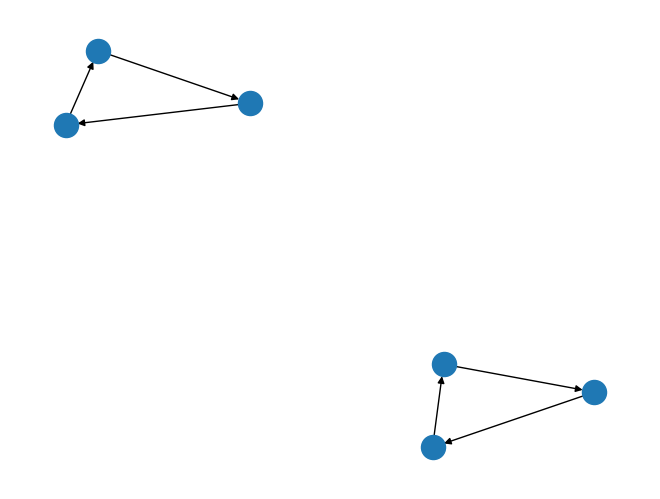

In [125]:
nx.draw(graph)

In [106]:
ceil_log_n2 = int(np.ceil(np.log2(n+2)))
circuit = QuantumCircuit()

# T * ceil_log_n2 + K * ceil_log_n2 + 1
registers = {f'solution_{t}' : QuantumRegister(ceil_log_n2 + 1, name=f'solution_{t}') for t in range(T)}
registers.update({'flag': QuantumRegister(1, name='flag')})
registers.update({'visits_flag': QuantumRegister(1, name='visits_flag')})
registers.update({f'next_node_{k}': QuantumRegister(ceil_log_n2 + 1, name=f'next_node_{k}') for k in range(K)})


for register in registers.values():
    circuit.add_register(register)
    
circuit = penalise_graph_steps(circuit, registers, 1, 1, np.pi/64, graph, n, K)
circuit.decompose().draw(fold=-1)

[('u0_+', 'u1_+'), ('u0_-', 'u2_+'), ('u1_+', 'u2_-'), ('u1_-', 'u0_-'), ('u2_+', 'u1_-'), ('u2_-', 'u0_+')]
3 1
('u0_-', 'u2_+')


solution_0_0: ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                                                                                                                                                                                                                         
 solution_0_1: ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                                                                                                                                                                                                                         
 solution_0_2: ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                                                                                                                                                                                                                         
 solution_0_3: ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                                                                                                                                                                                                                         
 solution_1_0: ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                                                                                                                                                                                                                         
 solution_1_1: ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                                                                                                                                                                                                                         
 solution_1_2: ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                                                                                                                                                                                                                         
 solution_1_3: ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
           

In [102]:
def penalise_graph_end_steps(
    circuit: QuantumCircuit, registers: dict, parameter: Parameter | ParameterExpression, n: int, K: int
) -> QuantumCircuit:
    """
    Appends a penalise_graph_end_steps subroutine to a circuit, which penalises any step from the end node to a non-end node.
    For each node j in 1..n:
        For each possible number of visits k:
            Checks if the kth next node register is equal to j, and flips a flag if so.
            Applies a phase to the flag qubit proportional to the parameter.
            Resets the flag.
    """
    for i in range(1, n+1):
        is_equal_circ = is_equal_to_without_parity(n, i)
        for k in range(K):
            circuit.append(
                is_equal_circ,
                list(range(
                    circuit.find_bit(registers[f'next_node_{k}'][1]).index, circuit.find_bit(registers[f'next_node_{k}'][-1]).index + 1
                )) + [circuit.find_bit(registers['flag'][0]).index]
            )
            circuit.p(
                parameter, 
                circuit.find_bit(registers['flag'][0]).index
            )
            circuit.append(
                is_equal_circ,
                list(range(
                    circuit.find_bit(registers[f'next_node_{k}'][1]).index, circuit.find_bit(registers[f'next_node_{k}'][-1]).index + 1
                )) + [circuit.find_bit(registers['flag'][0]).index]
            )
    return circuit

In [107]:
ceil_log_n2 = int(np.ceil(np.log2(n+2)))
circuit = QuantumCircuit()

# T * ceil_log_n2 + K * ceil_log_n2 + 1
registers = {f'solution_{t}' : QuantumRegister(ceil_log_n2 + 1, name=f'solution_{t}') for t in range(T)}
registers.update({'flag': QuantumRegister(1, name='flag')})
registers.update({'visits_flag': QuantumRegister(1, name='visits_flag')})
registers.update({f'next_node_{k}': QuantumRegister(ceil_log_n2 + 1, name=f'next_node_{k}') for k in range(K)})


for register in registers.values():
    circuit.add_register(register)
    
circuit = penalise_graph_end_steps(circuit, registers, np.pi/64, n, K)
circuit.decompose().draw(fold=-1)

solution_0_0: ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                                                                                                                     
 solution_0_1: ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                                                                                                                     
 solution_0_2: ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                                                                                                                     
 solution_0_3: ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                                                                                                                     
 solution_1_0: ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                                                                                                                     
 solution_1_1: ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                                                                                                                     
 solution_1_2: ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                                                                                                                     
 solution_1_3: ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                                                                                                                     
 solution_2_0: ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                                                                                                                     
 solution_2_1: ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                                                                                                                     
 solution_2_2: ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                                                                                                                                                     
 solution_2_3: ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
               ┌───┐┌─────────────┐┌───┐┌───┐┌─────────────┐┌───┐┌───┐┌─────────────┐┌───┐┌───┐┌─────────────┐┌───┐┌───┐┌─────────────┐┌───┐┌───┐┌─────────────┐┌───┐
         flag: ┤ 

In [110]:
def compute_next_nodes_without_parity(
        circuit: QuantumCircuit, registers: dict, j: int, n: int, K: int, T: int, parameter: Parameter | None
) -> QuantumCircuit:
    """
    Appends a compute_next_nodes subroutine to a circuit, which initialises registers .
    For t in 0..T-2:
        Checks if the t th solution register encodes j and flips a flag if so.
        If the flag is set, shuffles the next_node registers forward one place and copies the (t+1)th solution register to the next_node registers.
        Resets the flag.
    """    
    is_equal_circ = is_equal_to_without_parity(n, j)
    for t in range(T-1):
        circuit.append(
            is_equal_circ, 
            list(range(circuit.find_bit(registers[f'solution_{t}'][1]).index, circuit.find_bit(registers[f'solution_{t}'][-1]).index + 1)) \
                + [circuit.find_bit(registers['flag'][0]).index],
        )
        
        circuit.barrier()

        circuit = controlled_copy_with_swap(circuit, registers, K, t, parameter)
        
        circuit.barrier()

        circuit.append(
            is_equal_circ, 
            list(range(circuit.find_bit(registers[f'solution_{t}'][1]).index, circuit.find_bit(registers[f'solution_{t}'][-1]).index + 1)) \
                + [circuit.find_bit(registers['flag'][0]).index]
        )
    return circuit

In [ ]:
def uncompute_next_nodes_without_parity(
        circuit: QuantumCircuit, registers: dict, j: int, n: int, K: int, T: int
) -> QuantumCircuit:
    """
    Appends an uncompute_next_nodes subroutine to a circuit, which resets registers .
    For t in 0..T-2:
        Checks if the t th solution register encodes j and flips a flag if so.
        If the flag is set, shuffles the next_node registers forward one place and copies the (t+1)th solution register to the next_node registers.
        Resets the flag.
    """
    
    is_equal_circ = is_equal_to_without_parity(n, j)
    for t in range(T-1):
        circuit.append(
            is_equal_circ, 
            list(range(circuit.find_bit(registers[f'solution_{t}'][1]).index, circuit.find_bit(registers[f'solution_{t}'][-1]).index + 1)) \
                + [circuit.find_bit(registers['flag'][0]).index],
        )

        new_circuit = QuantumCircuit()
        for register in registers.values():
            new_circuit.add_register(register)
        new_circuit = controlled_copy_with_swap(new_circuit, registers, K, t, parameter=None)
        
        circuit.append(
            new_circuit.reverse_ops(),
            new_circuit.qubits
        )
        
        circuit.append(
            is_equal_circ, 
            list(range(circuit.find_bit(registers[f'solution_{t}'][1]).index, circuit.find_bit(registers[f'solution_{t}'][-1]).index + 1)) \
                + [circuit.find_bit(registers['flag'][0]).index]
        )
    return circuit

In [115]:
ceil_log_n2 = int(np.ceil(np.log2(n+2)))
circuit = QuantumCircuit()

# T * ceil_log_n2 + K * ceil_log_n2 + 1
registers = {f'solution_{t}' : QuantumRegister(ceil_log_n2 + 1, name=f'solution_{t}') for t in range(T)}
registers.update({'flag': QuantumRegister(1, name='flag')})
registers.update({'visits_flag': QuantumRegister(1, name='visits_flag')})
registers.update({f'next_node_{k}': QuantumRegister(ceil_log_n2 + 1, name=f'next_node_{k}') for k in range(K)})


for register in registers.values():
    circuit.add_register(register)
    
circuit = uncompute_next_nodes_without_parity(circuit, registers, n+1, n, K, T)
circuit.decompose(gates_to_decompose=['*circuit*']).draw(fold=-1)

solution_0_0: ──────────────────────■─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                                     │                                                                                                                                     
 solution_0_1: ──o──────────────■────┼────────────────────────────────────────────────────o────────────────────────────────────────────────────────────────────────────────
                 │              │    │                                                    │                                                                                
 solution_0_2: ──o─────────■────┼────┼────────────────────────────────────────────────────o────────────────────────────────────────────────────────────────────────────────
                 │         │    │    │                                                    │                                                                                
 solution_0_3: ──■────■────┼────┼────┼────────────────────────────────────────────────────■────────────────────────────────────────────────────────────────────────────────
                 │    │    │    │    │                                                    │                                                                                
 solution_1_0: ──┼────┼────┼────┼────┼────────────────────────────────────────────────────┼────────────────────────■───────────────────────────────────────────────────────
                 │    │    │    │    │                                                    │                        │                                                       
 solution_1_1: ──┼────┼────┼────┼────┼────────────────────────────────────────────────────┼────o──────────────■────┼────────────────────────────────────────────────────o──
                 │    │    │    │    │                                                    │    │              │    │                                                    │  
 solution_1_2: ──┼────┼────┼────┼────┼────────────────────────────────────────────────────┼────o─────────■────┼────┼────────────────────────────────────────────────────o──
                 │    │    │    │    │                                                    │    │         │    │    │                                                    │  
 solution_1_3: ──┼────┼────┼────┼────┼────────────────────────────────────────────────────┼────■────■────┼────┼────┼────────────────────────────────────────────────────■──
                 │    │    │    │    │                                                    │    │    │    │    │    │                                                    │  
 solution_2_0: ──┼────┼────┼────┼────┼────────────────────────────────────────────────────┼────┼────┼────┼────┼────┼────────────────────────────────────────────────────┼──
                 │    │    │    │    │                                                    │    │    │    │    │    │                                                    │  
 solution_2_1: ──┼────┼────┼────┼────┼────────────────────────────────────────────────────┼────┼────┼────┼────┼────┼────────────────────────────────────────────────────┼──
                 │    │    │    │    │                                                    │    │    │    │    │    │                                                    │  
 solution_2_2: ──┼────┼────┼────┼────┼────────────────────────────────────────────────────┼────┼────┼────┼────┼────┼────────────────────────────────────────────────────┼──
                 │    │    │    │    │                                                    │    │    │    │    │    │                                                    │  
 solution_2_3: ──┼────┼────┼────┼────┼────────────────────────────────────────────────────┼────┼────┼────┼────┼────┼────────────────────────────────────────────────────┼──
               ┌─┴─┐  │    │    │    │       

In [116]:
def compute_count(circuit: QuantumCircuit, registers: dict, j: int, n: int, K: int, T: int) -> QuantumCircuit:
    """
    Appends a compute_count subroutine to a circuit.
    For each register x_0 ... x_{T-1}, checks if the register encodes j in binary and flips a flag if so.
    Adds 1 to a count register based on the flag.
    Resets the flag.
    """
    is_equal_circ = is_equal_to_without_parity(n, j)

    for t in range(T):
        circuit.append(
            is_equal_circ, 
            list(range(circuit.find_bit(registers[f'solution_{t}'][1]).index, circuit.find_bit(registers[f'solution_{t}'][-1]).index + 1)) \
                + [circuit.find_bit(registers['flag'][0]).index]
        )
        
        # circuit.save_statevector(f'before_c_add_{j}_{t}')
        for i in range(registers['count'].size-1,0,-1):
            circuit.mcx(
                [circuit.find_bit(registers['flag'][0]).index] + list(range(circuit.find_bit(registers['count'][0]).index, circuit.find_bit(registers['count'][i]).index)),
                circuit.find_bit(registers['count'][i]).index
            )
        circuit.cx(circuit.find_bit(registers['flag'][0]).index, circuit.find_bit(registers['count'][0]).index)
        # circuit.save_statevector(f'after_c_add_{j}_{t}')
        circuit.append(
            is_equal_circ, 
            list(range(circuit.find_bit(registers[f'solution_{t}'][1]).index, circuit.find_bit(registers[f'solution_{t}'][-1]).index + 1)) \
                + [circuit.find_bit(registers['flag'][0]).index],
            
        )
        
    return circuit

In [118]:
ceil_log_n2 = int(np.ceil(np.log2(n+2)))
ceil_log_K1 = int(np.ceil(np.log2(K+1)))
circuit = QuantumCircuit()

# T * ceil_log_n2 + K * ceil_log_n2 + 1
registers = {f'solution_{t}' : QuantumRegister(ceil_log_n2 + 1, name=f'solution_{t}') for t in range(T)}
registers.update({'flag': QuantumRegister(1, name='flag')})
registers.update({'count': QuantumRegister(ceil_log_K1, name='count')})


for register in registers.values():
    circuit.add_register(register)
    
circuit = compute_count(circuit, registers, 1, n, K, T)
circuit.decompose(gates_to_decompose=['*circuit*']).draw(fold=-1)

solution_0_0: ────────────────────────────────────────────────────────────
                                                                          
solution_0_1: ──■──────────────■──────────────────────────────────────────
                │              │                                          
solution_0_2: ──o──────────────o──────────────────────────────────────────
                │              │                                          
solution_0_3: ──o──────────────o──────────────────────────────────────────
                │              │                                          
solution_1_0: ──┼──────────────┼──────────────────────────────────────────
                │              │                                          
solution_1_1: ──┼──────────────┼────■──────────────■──────────────────────
                │              │    │              │                      
solution_1_2: ──┼──────────────┼────o──────────────o──────────────────────
                │              │    │              │                      
solution_1_3: ──┼──────────────┼────o──────────────o──────────────────────
                │              │    │              │                      
solution_2_0: ──┼──────────────┼────┼──────────────┼──────────────────────
                │              │    │              │                      
solution_2_1: ──┼──────────────┼────┼──────────────┼────■──────────────■──
                │              │    │              │    │              │  
solution_2_2: ──┼──────────────┼────┼──────────────┼────o──────────────o──
                │              │    │              │    │              │  
solution_2_3: ──┼──────────────┼────┼──────────────┼────o──────────────o──
              ┌─┴─┐          ┌─┴─┐┌─┴─┐          ┌─┴─┐┌─┴─┐          ┌─┴─┐
        flag: ┤ X ├──■────■──┤ X ├┤ X ├──■────■──┤ X ├┤ X ├──■────■──┤ X ├
              └───┘  │  ┌─┴─┐└───┘└───┘  │  ┌─┴─┐└───┘└───┘  │  ┌─┴─┐└───┘
     count_0: ───────■──┤ X ├────────────■──┤ X ├────────────■──┤ X ├─────
                   ┌─┴─┐└───┘          ┌─┴─┐└───┘          ┌─┴─┐└───┘     
     count_1: ─────┤ X ├───────────────┤ X ├───────────────┤ X ├──────────
                   └───┘               └───┘               └───┘

In [131]:
def penalise_count(
        circuit: QuantumCircuit, registers: dict, j: int, parameter: Parameter, graph: nx.Graph, K: int
) -> QuantumCircuit:
    """
    Appends a penalise_count subroutine to a circuit for node j.
    For each possible number of visits to a node 0..K not equal to the weight of node j:
        Checks if count equals that number of visits and flips a flag.
        Applies a phase gate to the flag qubit based on the cost of that number of visits.
        Resets the flag.
    """
    ceil_log_K1 = int(np.ceil(np.log2(K+1)))
    nodes = list(graph.nodes)
    print(graph.nodes[nodes[2*(j-1)]]["weight"])
    for i in range(2 ** ceil_log_K1):
        if not graph.nodes[nodes[2*(j-1)]]["weight"] - i == 0:
            circuit.mcx(
                list(range(circuit.find_bit(registers['count'][0]).index, circuit.find_bit(registers['count'][-1]).index + 1)),
                circuit.find_bit(registers['flag'][0]).index,
                ctrl_state=i
            )
            circuit.p(parameter * (graph.nodes[nodes[2*(j-1)]]["weight"] - i) ** 2, circuit.find_bit(registers['flag'][0]).index)
            circuit.mcx(
                list(range(circuit.find_bit(registers['count'][0]).index, circuit.find_bit(registers['count'][-1]).index + 1)),
                circuit.find_bit(registers['flag'][0]).index,
                ctrl_state=i
            )
            
    return circuit

In [137]:
ceil_log_n2 = int(np.ceil(np.log2(n+2)))
ceil_log_K1 = int(np.ceil(np.log2(K+1)))
circuit = QuantumCircuit()

# T * ceil_log_n2 + K * ceil_log_n2 + 1
registers = {f'solution_{t}' : QuantumRegister(ceil_log_n2 + 1, name=f'solution_{t}') for t in range(T)}
registers.update({'flag': QuantumRegister(1, name='flag')})
registers.update({'count': QuantumRegister(ceil_log_K1, name='count')})


for register in registers.values():
    circuit.add_register(register)
    
circuit = penalise_count(circuit, registers, 3, np.pi/64, graph, K)
circuit.decompose(gates_to_decompose=['*circuit*']).draw(fold=-1)

2


solution_0_0: ───────────────────────────────────────────────────────────────
                                                                             
solution_0_1: ───────────────────────────────────────────────────────────────
                                                                             
solution_0_2: ───────────────────────────────────────────────────────────────
                                                                             
solution_0_3: ───────────────────────────────────────────────────────────────
                                                                             
solution_1_0: ───────────────────────────────────────────────────────────────
                                                                             
solution_1_1: ───────────────────────────────────────────────────────────────
                                                                             
solution_1_2: ───────────────────────────────────────────────────────────────
                                                                             
solution_1_3: ───────────────────────────────────────────────────────────────
                                                                             
solution_2_0: ───────────────────────────────────────────────────────────────
                                                                             
solution_2_1: ───────────────────────────────────────────────────────────────
                                                                             
solution_2_2: ───────────────────────────────────────────────────────────────
                                                                             
solution_2_3: ───────────────────────────────────────────────────────────────
              ┌───┐┌─────────┐┌───┐┌───┐┌─────────┐┌───┐┌───┐┌─────────┐┌───┐
        flag: ┤ X ├┤ P(π/16) ├┤ X ├┤ X ├┤ P(π/64) ├┤ X ├┤ X ├┤ P(π/64) ├┤ X ├
              └─┬─┘└─────────┘└─┬─┘└─┬─┘└─────────┘└─┬─┘└─┬─┘└─────────┘└─┬─┘
     count_0: ──o───────────────o────■───────────────■────■───────────────■──
                │               │    │               │    │               │  
     count_1: ──o───────────────o────o───────────────o────■───────────────■──

In [129]:
list(graph.nodes)

['u0_+', 'u0_-', 'u1_+', 'u1_-', 'u2_+', 'u2_-']

In [140]:
def uniform_over_range(num_qubits: int, M: int):
    """
    Returns a circuit that prepares a uniform superposition over |1>,|2>,...,|M> on num_qubits qubits.
    Uses a Hadamard layer if M is a power of 2, else uses the method of Shukla and Vedula.
    """
    if M not in range(2, 2 ** num_qubits + 1):
        raise Exception('Bad M: out of range')
    for i in range(num_qubits):
        if M == 2 ** i:
            print(f'M={M} a power of 2. Use Hadamard circuit.')
            circuit = QuantumCircuit(num_qubits)
            for j in range(i):
                circuit.h(j)
                
            for i in range(num_qubits-1,0,-1):
                circuit.mcx(list(range(i)), i)
            circuit.x(0)
            
            return circuit
    
    circuit = QuantumCircuit(num_qubits)

    M_binary = np.binary_repr(M, num_qubits)
    M_binary = M_binary[::-1]
    ran = np.arange(len(M_binary))
    mask = [M_binary[x] == '1' for x in range(len(M_binary))]
    l = ran[mask]
    
    for i in range(1, len(l)):
        circuit.x(l[i])
    if l[0] > 0:
        for i in range(l[0]):
            circuit.h(i)

    MM = 2 ** l[0]

    circuit.ry(-2 * np.arccos(np.sqrt(MM/M)), l[1])

    for i in range(l[0], l[1]):
        circuit.ch(l[1], i, ctrl_state=0)

    for m in range(1, len(l)-1):
        circuit.cry(
            -2 * np.arccos(np.sqrt(2 ** l[m] / (M - MM) )), 
            l[m], l[m+1], ctrl_state=0
        )
        for i in range(l[m], l[m+1]):
            circuit.ch(l[m+1], i, ctrl_state=0)
        MM += 2 ** l[m]

    for i in range(num_qubits-1,0,-1):
        circuit.mcx(list(range(i)), i)
    circuit.x(0)
    return circuit


def state_prep(n: int, T: int) -> QuantumCircuit:
    ceil_log_n2 = int(np.ceil(np.log2(n+2)))
    uni = uniform_over_range(ceil_log_n2, n+1)
    circuit = QuantumCircuit((ceil_log_n2+1) * T)
    for t in range(T):
        circuit.h(t*(ceil_log_n2+1))
        circuit.append(
            uni,
            list(range(t*(ceil_log_n2+1) + 1, (t+1)*(ceil_log_n2+1)))   
        )
    return circuit

In [150]:
circuit = state_prep(3, 2)
backend = AerSimulator()
t_circuit = transpile(circuit, backend, optimization_level=3)
t_circuit.measure_all()
result = backend.run(t_circuit).result()
print(sorted(result.get_counts().keys()))
circuit.decompose(gates_to_decompose=['*circuit*']).draw(fold=-1)

M=4 a power of 2. Use Hadamard circuit.
['00100010', '00100011', '00100100', '00100101', '00100110', '00100111', '00101000', '00101001', '00110010', '00110011', '00110100', '00110101', '00110110', '00110111', '00111000', '00111001', '01000010', '01000011', '01000100', '01000101', '01000110', '01000111', '01001000', '01001001', '01010010', '01010011', '01010100', '01010101', '01010110', '01010111', '01011000', '01011001', '01100010', '01100011', '01100100', '01100101', '01100110', '01100111', '01101000', '01101001', '01110010', '01110011', '01110100', '01110101', '01110110', '01110111', '01111000', '01111001', '10000010', '10000011', '10000100', '10000101', '10000110', '10000111', '10001000', '10001001', '10010010', '10010011', '10010100', '10010101', '10010110', '10010111', '10011000', '10011001']


┌───┐               
q_0: ┤ H ├───────────────
     ├───┤          ┌───┐
q_1: ┤ H ├──■────■──┤ X ├
     ├───┤  │  ┌─┴─┐└───┘
q_2: ┤ H ├──■──┤ X ├─────
     └───┘┌─┴─┐└───┘     
q_3: ─────┤ X ├──────────
     ┌───┐└───┘          
q_4: ┤ H ├───────────────
     ├───┤          ┌───┐
q_5: ┤ H ├──■────■──┤ X ├
     ├───┤  │  ┌─┴─┐└───┘
q_6: ┤ H ├──■──┤ X ├─────
     └───┘┌─┴─┐└───┘     
q_7: ─────┤ X ├──────────
          └───┘